# AI in Healthcare - Lab Assignment 2

**Name:** Vanshika Jain
**Course:** CSET343 - AI in Healthcare

**Objective:** Doing data cleaning and enrichment on the Heart Failure clinical dataset which has missing values.

## Task 1 & 2: Getting the dataset and loading it

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(url)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Task 3: Summary of the dataset

In [2]:
print("rows and columns:", df.shape)
print()
print("data types:")
print(df.dtypes)

rows and columns: (299, 13)

data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [3]:
# checking missing values in each column
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


Note: this dataset from UCI actually doesn't have any missing values by default, so I am adding some missing values on purpose (randomly) so I can practice the cleaning steps asked in the assignment.

In [4]:
# adding some random missing values so we have something to clean
np.random.seed(42)

df_missing = df.copy()

for col in ["age", "ejection_fraction", "serum_creatinine", "platelets"]:
    idx = df_missing.sample(frac=0.05, random_state=1).index
    df_missing.loc[idx, col] = np.nan

df = df_missing
df.isnull().sum()

,0
age,15
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,15
high_blood_pressure,0
platelets,15
serum_creatinine,15
serum_sodium,0
sex,0


## Task 4: Visualizing missing values with a heatmap

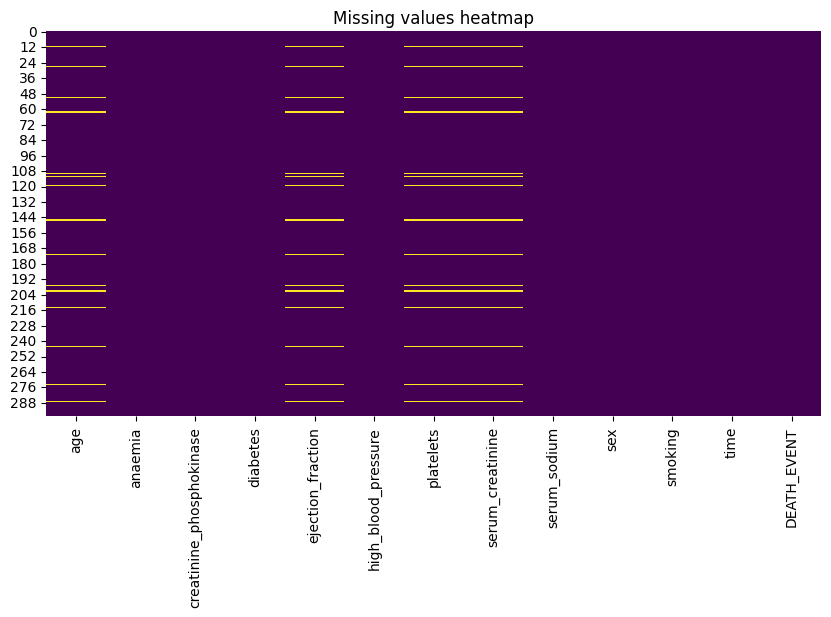

In [5]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing values heatmap")
plt.show()

## Task 5: Plotting distributions of some numerical columns

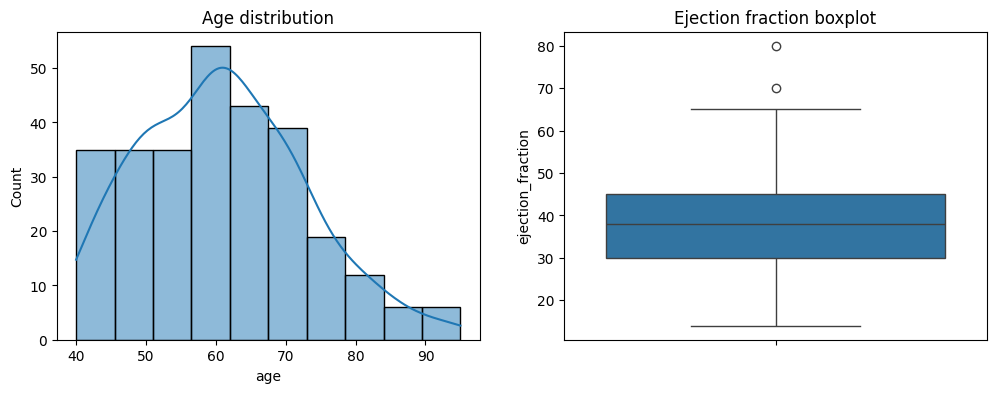

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df["age"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Age distribution")

sns.boxplot(y=df["ejection_fraction"].dropna(), ax=axes[1])
axes[1].set_title("Ejection fraction boxplot")

plt.show()

## Task 6: Filling in the missing values

In [7]:
# numerical columns - filling with median
for col in ["age", "ejection_fraction", "serum_creatinine", "platelets"]:
    df[col] = df[col].fillna(df[col].median())

# smoking is categorical (0/1) in this dataset, filling with mode
df["smoking"] = df["smoking"].fillna(df["smoking"].mode()[0])

df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


## Task 7: Removing outliers
Using the IQR method on a couple of numeric columns.

In [8]:
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

print("rows before removing outliers:", df.shape[0])

for col in ["creatinine_phosphokinase", "platelets", "serum_creatinine"]:
    df = remove_outliers_iqr(df, col)

print("rows after removing outliers:", df.shape[0])

rows before removing outliers: 299
rows after removing outliers: 229


## Task 8: Fixing inconsistent entries
Checking for things like negative age which don't make sense.

In [9]:
# check for negative or weird values in age
print("negative ages found:", (df["age"] < 0).sum())

# fix if any found (taking absolute value just in case)
df["age"] = df["age"].abs()

# also age should realistically be less than 120
df = df[df["age"] < 120]

df["age"].describe()

negative ages found: 0


,age
count,229.000000
mean,60.560410
std,11.548899
min,40.000000
25%,51.000000
50%,60.000000
75%,68.000000
max,95.000000


## Task 9: Feature engineering
Making 2 new columns - age_group and risk_score

In [10]:
# age_group feature
bins = [0, 40, 60, 200]
labels = ["<40", "40-60", ">60"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

df["age_group"].value_counts()

,count
age_group,
40-60,119
>60,103
<40,7


In [11]:
# risk_score feature - normalized product of ejection_fraction and serum_creatinine
ef_norm = (df["ejection_fraction"] - df["ejection_fraction"].min()) / (df["ejection_fraction"].max() - df["ejection_fraction"].min())
sc_norm = (df["serum_creatinine"] - df["serum_creatinine"].min()) / (df["serum_creatinine"].max() - df["serum_creatinine"].min())

df["risk_score"] = ef_norm * sc_norm

df[["ejection_fraction", "serum_creatinine", "risk_score"]].head()

,ejection_fraction,serum_creatinine,risk_score
0,20.0,1.9,0.078788
2,20.0,1.3,0.042424
3,20.0,1.9,0.078788
5,40.0,2.1,0.393939
6,15.0,1.2,0.006061


## Task 10: Encoding categorical variables

In [12]:
# age_group is categorical, using one-hot encoding on it
df = pd.get_dummies(df, columns=["age_group"], prefix="age_group")

# sex and smoking are already 0/1 in this dataset so no need to encode them again
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582,0,20.0,1,265000.0,1.9,130,1,0,4,1,0.078788,False,False,True
2,65.0,0,146,0,20.0,0,162000.0,1.3,129,1,1,7,1,0.042424,False,False,True
3,50.0,1,111,0,20.0,0,210000.0,1.9,137,1,0,7,1,0.078788,False,True,False
5,90.0,1,47,0,40.0,1,204000.0,2.1,132,1,1,8,1,0.393939,False,False,True
6,75.0,1,246,0,15.0,0,127000.0,1.2,137,1,0,10,1,0.006061,False,False,True


## Task 11: Normalizing numerical features (0 to 1)

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = ["age", "platelets", "creatinine_phosphokinase", "ejection_fraction", "serum_creatinine", "serum_sodium"]

df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

df_scaled[num_cols].head()

,age,platelets,creatinine_phosphokinase,ejection_fraction,serum_creatinine,serum_sodium
0,0.636364,0.523529,0.467401,0.090909,0.866667,0.485714
2,0.454545,0.220588,0.098222,0.090909,0.466667,0.457143
3,0.181818,0.361765,0.068586,0.090909,0.866667,0.685714
5,0.909091,0.344118,0.014395,0.393939,1.000000,0.542857
6,0.636364,0.117647,0.182896,0.015152,0.400000,0.685714


## Task 12: Summary statistics before and after cleaning

In [14]:
print("BEFORE cleaning (original downloaded data):")
print(pd.read_csv(url)[num_cols].agg(["mean","median","std"]))

print()
print("AFTER cleaning and normalizing:")
print(df_scaled[num_cols].agg(["mean","median","std"]))

BEFORE cleaning (original downloaded data):
              age      platelets  creatinine_phosphokinase  ejection_fraction  \
mean    60.833893  263358.029264                581.839465          38.083612   
median  60.000000  262000.000000                250.000000          38.000000   
std     11.894809   97804.236869                970.287881          11.834841   

        serum_creatinine  serum_sodium  
mean             1.39388    136.625418  
median           1.10000    137.000000  
std              1.03451      4.412477  

AFTER cleaning and normalizing:
             age  platelets  creatinine_phosphokinase  ejection_fraction  \
mean    0.373826   0.493555                  0.265226           0.371311   
median  0.363636   0.514706                  0.154953           0.363636   
std     0.209980   0.192049                  0.240458           0.176163   

        serum_creatinine  serum_sodium  
mean            0.357060      0.679726  
median          0.333333      0.685714  
std   

## Task 13: Checking the cleaned data with plots again

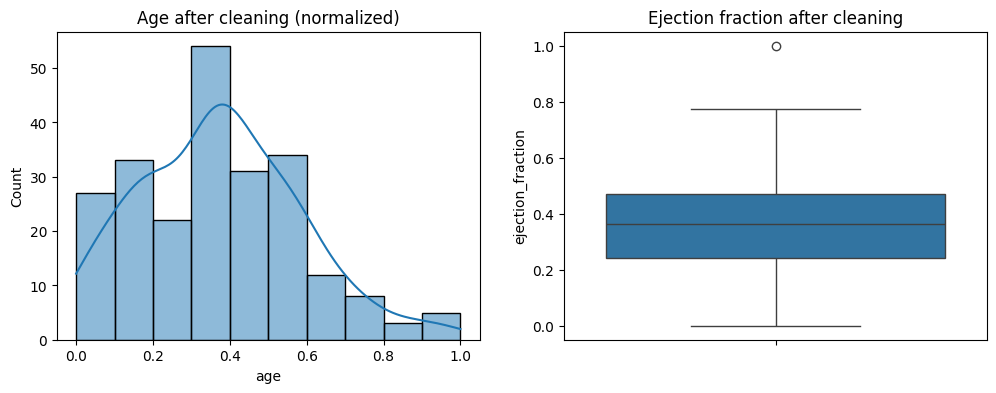

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df_scaled["age"], kde=True, ax=axes[0])
axes[0].set_title("Age after cleaning (normalized)")

sns.boxplot(y=df_scaled["ejection_fraction"], ax=axes[1])
axes[1].set_title("Ejection fraction after cleaning")

plt.show()

## Task 14: Final check for missing values

In [16]:
df_scaled.isnull().sum().sum()

np.int64(0)

No missing values left, output above is 0. So the dataset is fully cleaned now - missing values handled, outliers removed, inconsistent age values fixed, 2 new features added (age_group, risk_score), categorical columns encoded, and numeric columns normalized between 0 and 1.